# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

#df = pd.read_parquet('/content/2023-1.parquet')
#df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/IIITB/EDA Assignment/Datasets and Dictionary-NYC/Datasets and Dictionary/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_data = pd.read_parquet(file_path, engine='pyarrow')

        # Create date and hour columns
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour



        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for pickup_date in month_data['pickup_date'].unique():

            # Iterate through each hour of the selected date
            for pickup_hour in range(24):
                # Filter data for the current date and hour
                hour_data = month_data[(month_data['pickup_date'] == pickup_date) & (month_data['pickup_hour'] == pickup_hour)]


                # Sample 5% of the hourly data randomly
                sample = hour_data.sample(frac=0.05, random_state=42)

                # Append the sampled data to the sampled_data dataframe
                sampled_data = pd.concat([sampled_data, sample])

                # add data of this hour to the dataframe


        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data],ignore_index=True)
        print(
            file_name,
            "-> Monthly sample:",
            len(sampled_data),
            "| Total sample:",
            len(df)
        )

    except FileNotFoundError:
        print(f"File {file_name} not found.")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

2023-2.parquet -> Monthly sample: 168696 | Total sample: 168696
2023-11.parquet -> Monthly sample: 165133 | Total sample: 333829
2023-6.parquet -> Monthly sample: 162910 | Total sample: 496739
2023-4.parquet -> Monthly sample: 139641 | Total sample: 636380
2023-8.parquet -> Monthly sample: 143782 | Total sample: 780162
2023-9.parquet -> Monthly sample: 140875 | Total sample: 921037
2023-5.parquet -> Monthly sample: 144458 | Total sample: 1065495
2023-12.parquet -> Monthly sample: 166709 | Total sample: 1232204
2023-10.parquet -> Monthly sample: 174255 | Total sample: 1406459
2023-3.parquet -> Monthly sample: 163786 | Total sample: 1570245
2023-7.parquet -> Monthly sample: 174068 | Total sample: 1744313
2023-1.parquet -> Monthly sample: 152087 | Total sample: 1896400


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
working_folder = '/content/drive/MyDrive/IIITB/EDA Assignment/683eb526-56d0-483e-b940-287fbdee518c-APAGAI-Assignment-EDA/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/working_copy'
df = pd.read_parquet(working_folder + '/nyc_taxi_2023_sampled.parquet')
df.shape

(1896400, 21)

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee
0,1,2023-03-01 00:06:18,2023-03-01 00:21:33,1.0,7.90,1.0,N,138,236,1,...,9.75,0.5,9.75,6.55,1.0,58.55,2.5,2023-03-01,0,1.25
1,2,2023-03-01 00:40:10,2023-03-01 00:45:44,1.0,1.55,1.0,N,113,164,1,...,1.00,0.5,2.72,0.00,1.0,16.32,2.5,2023-03-01,0,0.00
2,2,2023-03-01 00:08:41,2023-03-01 00:12:28,4.0,0.73,1.0,N,238,166,1,...,1.00,0.5,1.80,0.00,1.0,10.80,0.0,2023-03-01,0,0.00
3,1,2023-03-01 00:37:43,2023-03-01 00:55:51,1.0,4.60,1.0,N,249,262,1,...,3.50,0.5,20.00,0.00,1.0,48.30,2.5,2023-03-01,0,0.00
4,2,2023-03-01 00:08:01,2023-03-01 00:14:41,1.0,1.33,1.0,N,249,68,1,...,1.00,0.5,2.72,0.00,1.0,16.32,2.5,2023-03-01,0,0.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  pickup_date           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
df.columns.tolist()


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_date',
 'pickup_hour',
 'airport_fee']

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns

df['airport_fee'] = df['Airport_fee'].fillna(df['airport_fee'])

# Remove the redundant column
df.drop(columns=['Airport_fee'], inplace=True)

df.columns.tolist()


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_date',
 'pickup_hour',
 'airport_fee']

In [ ]:
df['airport_fee'].value_counts(dropna=False)

,count
airport_fee,
0.00,1670565
1.75,121123
NaN,64874
1.25,39823
-1.75,11
-1.25,3
1.00,1


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative

df[df['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
negative_fare = df[df['fare_amount'] < 0]

negative_fare['RatecodeID'].value_counts(dropna=False)


,count
RatecodeID,


In [ ]:
# Find which columns have negative values
negative_counts = {}

for column in df.select_dtypes(include=['int64', 'float64']).columns:
    count = (df[column] < 0).sum()

    if count > 0:
        negative_counts[column] = count

negative_counts


{'airport_fee': np.int64(14)}

In [ ]:
# Finding negative records

negative_records = df[
    (df['extra'] < 0) |
    (df['mta_tax'] < 0) |
    (df['improvement_surcharge'] < 0) |
    (df['total_amount'] < 0) |
    (df['congestion_surcharge'] < 0) |
    (df['airport_fee'] < 0)
]

negative_records[
    [
        'RatecodeID',
        'fare_amount',
        'extra',
        'mta_tax',
        'improvement_surcharge',
        'total_amount',
        'congestion_surcharge',
        'airport_fee'
    ]
]

,RatecodeID,fare_amount,extra,mta_tax,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
67652,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.25
78135,2.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.25
197135,4.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75
232356,2.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75
299111,2.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75
358121,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75
630803,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75
994922,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.25
1166841,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75
1320010,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.75


In [ ]:
# fix these negative values
monetary_columns = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

for column in monetary_columns:
    df[column] = df[column].clip(lower=0)

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column

(df.isnull().mean() * 100).sort_values(ascending=False)


,0
passenger_count,3.420903
airport_fee,3.420903
congestion_surcharge,3.420903
store_and_fwd_flag,3.420903
RatecodeID,3.420903
trip_distance,0.000000
tpep_dropoff_datetime,0.000000
tpep_pickup_datetime,0.000000
VendorID,0.000000
payment_type,0.000000


In [ ]:
missing_rows = df[
    df[['passenger_count',
        'airport_fee',
        'congestion_surcharge',
        'store_and_fwd_flag',
        'RatecodeID']].isnull().any(axis=1)
]

missing_rows.shape

(64874, 21)

In [ ]:
missing_rows[
    ['passenger_count',
     'airport_fee',
     'congestion_surcharge',
     'store_and_fwd_flag',
     'RatecodeID']
].isnull().sum()

,0
passenger_count,64874
airport_fee,64874
congestion_surcharge,64874
store_and_fwd_flag,64874
RatecodeID,64874


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
df[df['passenger_count'].isnull()]

df['passenger_count'].value_counts(dropna=False).sort_index()


,count
passenger_count,
0.0,29681
1.0,1377224
2.0,277298
3.0,69034
4.0,38537
5.0,23871
6.0,15860
7.0,5
8.0,11


In [ ]:
#Median value of passenger_count
median_passenger_count = df['passenger_count'].median()

median_passenger_count

1.0

In [ ]:
# Impute NaN values with Median value in 'passenger_count'
df['passenger_count'] = df['passenger_count'].fillna(median_passenger_count)
df['passenger_count'].isnull().sum()

np.int64(0)

In [ ]:
df['passenger_count'].value_counts().sort_index()

,count
passenger_count,
0.0,29681
1.0,1442098
2.0,277298
3.0,69034
4.0,38537
5.0,23871
6.0,15860
7.0,5
8.0,11


Did you find zeroes in passenger_count? Handle these.

In [ ]:
zero_passengers = df[df['passenger_count'] == 0]

zero_passengers.shape

(29681, 21)

In [ ]:
zero_passengers[
    ['tpep_pickup_datetime',
     'tpep_dropoff_datetime',
     'trip_distance',
     'fare_amount',
     'total_amount']
].head(10)

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount
120,2023-03-01 01:03:35,2023-03-01 01:19:17,4.6,21.9,30.90
188,2023-03-01 05:54:52,2023-03-01 06:05:12,3.3,15.6,24.70
234,2023-03-01 06:04:28,2023-03-01 06:35:38,16.8,83.9,137.25
404,2023-03-01 07:56:35,2023-03-01 08:02:01,0.9,7.9,14.25
510,2023-03-01 08:16:09,2023-03-01 08:49:23,11.6,47.8,74.60
600,2023-03-01 08:18:12,2023-03-01 08:22:37,0.9,6.5,12.60
673,2023-03-01 08:41:27,2023-03-01 08:50:39,1.4,9.3,15.69
737,2023-03-01 08:05:30,2023-03-01 08:31:15,3.4,24.0,33.60
878,2023-03-01 09:45:29,2023-03-01 10:13:54,1.8,24.0,29.00
958,2023-03-01 09:10:31,2023-03-01 09:23:28,1.6,13.5,20.13


In [ ]:
# Impute zero values in 'passenger_count' with median
df.loc[df['passenger_count'] == 0, 'passenger_count'] = median_passenger_count
df['passenger_count'].value_counts().sort_index()

,count
passenger_count,
1.0,1471779
2.0,277298
3.0,69034
4.0,38537
5.0,23871
6.0,15860
7.0,5
8.0,11
9.0,5


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
df.RatecodeID.isna().sum()
df['RatecodeID'].value_counts(dropna=False).sort_index()
ratecode_mode = df['RatecodeID'].mode()[0]
# Impute missing values with mode
df['RatecodeID'] = df['RatecodeID'].fillna(ratecode_mode)
df['RatecodeID'].value_counts(dropna=False).sort_index()

,count
RatecodeID,
1.0,1794133
2.0,71670
3.0,6124
4.0,3723
5.0,10275
6.0,3
99.0,10472


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge

df['congestion_surcharge'].value_counts(dropna=False).sort_index()


,count
congestion_surcharge,
0.0,140953
0.5,1
2.5,1690572
NaN,64874


In [ ]:
df['congestion_surcharge'].mean()


np.float64(2.307600601902457)

In [ ]:
df['congestion_surcharge'].median()

2.5

In [ ]:
# Impute with Median value as the overwhelming majority of valid values are 2.5

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].median())
df.congestion_surcharge.isna().sum()


np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
# Handling missing value for store_and_fwd_flg column

df['store_and_fwd_flag'].value_counts(dropna=False)
#Impute with mode value
store_flag_mode = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(store_flag_mode)
df['store_and_fwd_flag'].value_counts(dropna=False)


,count
store_and_fwd_flag,
N,1885161
Y,11239


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,1896400.0,1.733026,1.0,1.0,2.0,2.0,6.0,0.44764
tpep_pickup_datetime,1896400,2023-07-02 19:59:52.930795,2022-12-31 23:51:30,2023-04-02 16:10:08.750000,2023-06-27 15:44:22.500000,2023-10-06 19:37:45,2023-12-31 23:57:51,NaN
tpep_dropoff_datetime,1896400,2023-07-02 20:17:18.919562,2022-12-31 23:56:06,2023-04-02 16:27:43.500000,2023-06-27 16:01:15,2023-10-06 19:53:39,2024-01-01 20:50:55,NaN
passenger_count,1896400.0,1.372236,1.0,1.0,1.0,1.0,9.0,0.864404
trip_distance,1896400.0,3.858293,0.0,1.05,1.79,3.4,126360.46,129.40854
RatecodeID,1896400.0,1.612981,1.0,1.0,1.0,1.0,99.0,7.267261
PULocationID,1896400.0,165.281376,1.0,132.0,162.0,234.0,265.0,64.000377
DOLocationID,1896400.0,164.05152,1.0,114.0,162.0,234.0,265.0,69.802066
payment_type,1896400.0,1.163817,0.0,1.0,1.0,1.0,4.0,0.508138
fare_amount,1896400.0,19.91935,0.0,9.3,13.5,21.9,143163.45,105.537084


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

In [ ]:
# Trips with almost zero distance but unusually high fare

df[(df['trip_distance'] < 0.1) &
   (df['fare_amount'] > 300)].shape

(35, 21)

In [ ]:
df[(df['trip_distance'] < 0.1) &
   (df['fare_amount'] > 300)][
    ['tpep_pickup_datetime',
     'tpep_dropoff_datetime',
     'PULocationID',
     'DOLocationID',
     'trip_distance',
     'fare_amount',
     'total_amount']
]

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount
165979,2023-03-31 16:56:04,2023-03-31 16:57:02,181,181,0.00,500.00,501.00
315204,2023-11-26 16:04:06,2023-11-26 16:04:12,265,265,0.00,305.14,367.37
364141,2023-04-05 21:16:43,2023-04-05 21:25:57,265,265,0.00,600.00,601.00
494516,2023-04-30 14:21:36,2023-04-30 14:22:11,130,93,0.08,800.00,801.00
497946,2023-08-01 11:12:09,2023-08-01 11:12:09,264,264,0.00,425.00,425.00
501253,2023-08-01 22:06:03,2023-08-01 22:06:41,39,39,0.00,500.00,501.00
555855,2023-08-13 18:44:08,2023-08-13 18:44:22,265,265,0.00,500.00,501.00
588053,2023-08-20 21:39:04,2023-08-20 21:39:12,132,132,0.00,399.00,400.00
588062,2023-08-20 21:56:48,2023-08-20 21:56:59,185,185,0.00,330.00,331.00
608450,2023-08-25 16:13:28,2023-08-25 16:13:42,265,265,0.00,350.00,354.33


In [ ]:
# Trips with zero distance and zero fare but different pickup/drop-off zones

zero_distance_fare = df[
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
]

zero_distance_fare.shape

(63, 21)

In [ ]:
zero_distance_fare[
    ['tpep_pickup_datetime',
     'tpep_dropoff_datetime',
     'PULocationID',
     'DOLocationID',
     'trip_distance',
     'fare_amount',
     'total_amount']
]

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount
24870,2023-03-03 12:13:56,2023-03-03 12:15:45,170,137,0.0,0.0,0.0
45563,2023-03-09 11:16:27,2023-03-09 12:23:00,161,119,0.0,0.0,0.0
72113,2023-03-14 09:05:35,2023-03-14 09:11:05,35,177,0.0,0.0,0.0
204405,2023-11-07 08:42:41,2023-11-07 08:42:41,237,264,0.0,0.0,0.0
209615,2023-11-08 04:38:05,2023-11-08 04:41:18,233,107,0.0,0.0,0.0
...,...,...,...,...,...,...,...
1787994,2023-01-10 19:28:41,2023-01-10 20:14:48,127,91,0.0,0.0,0.0
1827361,2023-01-18 15:42:00,2023-01-18 15:42:00,161,264,0.0,0.0,0.0
1827560,2023-01-18 16:23:49,2023-01-18 16:23:49,239,264,0.0,0.0,0.0
1835034,2023-01-19 21:57:21,2023-01-19 22:17:44,170,75,0.0,0.0,2.0


In [ ]:
# Find trips with unusually high trip distance

long_trips = df[df['trip_distance'] > 250]

long_trips.shape

(46, 21)

In [ ]:
long_trips[
    ['tpep_pickup_datetime',
     'tpep_dropoff_datetime',
     'PULocationID',
     'DOLocationID',
     'trip_distance',
     'fare_amount',
     'total_amount']
]

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount
14042,2023-03-02 15:45:34,2023-03-02 16:00:45,161,68,9674.01,14.20,20.20
27238,2023-03-03 19:47:00,2023-03-03 20:05:00,75,42,7094.16,18.81,20.31
54499,2023-03-10 19:12:22,2023-03-10 19:18:55,140,263,10961.43,8.60,15.10
159642,2023-03-30 14:07:00,2023-03-30 15:32:00,50,132,12133.27,77.00,97.20
281985,2023-11-20 11:46:00,2023-11-20 12:30:00,179,237,22869.37,27.39,31.39
396972,2023-04-17 10:56:00,2023-04-17 11:25:00,89,227,7914.69,19.85,21.35
466124,2023-04-22 14:58:35,2023-04-22 15:23:03,144,237,403.66,24.00,30.00
577544,2023-08-18 14:26:43,2023-08-18 15:04:09,71,39,56823.80,18.50,20.00
674418,2023-07-10 17:33:19,2023-07-10 19:14:56,216,265,9717.11,264.80,271.30
685882,2023-07-12 21:05:00,2023-07-12 21:10:00,263,263,30430.04,23.01,27.01


In [ ]:
# Find records with invalid payment_type = 0

invalid_payment = df[df['payment_type'] == 0]

invalid_payment.shape

(64874, 21)

In [ ]:
invalid_payment[
    ['payment_type',
     'trip_distance',
     'fare_amount',
     'total_amount',
     'PULocationID',
     'DOLocationID']
]

,payment_type,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID
6,0,3.43,16.77,23.87,137,236
97,0,3.82,15.04,20.94,238,233
134,0,2.20,11.38,18.46,142,236
168,0,4.29,17.72,26.06,249,141
172,0,7.68,31.12,50.00,262,138
...,...,...,...,...,...,...
1896184,0,2.87,15.72,25.64,161,263
1896233,0,2.90,16.30,23.43,48,141
1896300,0,14.14,58.25,71.59,231,197
1896351,0,3.23,16.92,25.10,230,4


In [ ]:
invalid_payment_count = (df['payment_type'] == 0).sum()

print("Invalid payment_type records:", invalid_payment_count)

Invalid payment_type records: 64874


In [ ]:
# Removing these 64,874 records of payment_type = 0, which is an invalid/unrecognized category, and there is no reliable basis to infer the actual payment type.
# Since this is only about 3.42% of your 1,896,400 records

df = df[df['payment_type'] != 0].copy()

In [ ]:
df['payment_type'].value_counts().sort_index()

,count
payment_type,
1,1492374
2,316452
3,9015
4,13685


How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6].copy()

In [ ]:
df['passenger_count'].value_counts().sort_index()

,count
passenger_count,
1.0,1406905
2.0,277298
3.0,69034
4.0,38537
5.0,23871
6.0,15860


In [ ]:
df.shape

(1831505, 21)

In [ ]:
# Continue with outlier handling

# Remove trips with near-zero distance and unusually high fare
df = df[~((df['trip_distance'] < 0.1) &
          (df['fare_amount'] > 300))].copy()


In [ ]:
((df['trip_distance'] < 0.1) &
 (df['fare_amount'] > 300)).sum()

np.int64(0)

In [ ]:
# Remove zero-distance and zero-fare trips between different zones
df = df[~(
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
)].copy()

In [ ]:
((df['trip_distance'] == 0) &
 (df['fare_amount'] == 0) &
 (df['PULocationID'] != df['DOLocationID'])).sum()

np.int64(0)

In [ ]:
# Remove trips with unusually high distance
df = df[df['trip_distance'] <= 250].copy()

In [ ]:
(df['trip_distance'] > 250).sum()

np.int64(0)

In [ ]:
df.shape

(1831391, 21)

In [ ]:
df[['passenger_count',
    'trip_distance',
    'fare_amount',
    'total_amount']].describe()

,passenger_count,trip_distance,fare_amount,total_amount
count,1.831391e+06,1.831391e+06,1.831391e+06,1.831391e+06
mean,1.385349e+00,3.444838e+00,1.981667e+01,2.894021e+01
std,8.764050e-01,4.545772e+00,1.073392e+02,1.082167e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.050000e+00,9.300000e+00,1.596000e+01
50%,1.000000e+00,1.780000e+00,1.350000e+01,2.100000e+01
75%,1.000000e+00,3.370000e+00,2.190000e+01,3.070000e+01
max,6.000000e+00,2.048600e+02,1.431635e+05,1.431675e+05


In [ ]:
# Inspect the highest fare records
df.nlargest(
    20,
    'fare_amount'
)[[
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'trip_distance',
    'fare_amount',
    'total_amount',
    'payment_type'
]]

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount,payment_type
796986,2023-09-05 10:16:13,2023-09-05 10:20:56,249,90,0.70,143163.45,143167.45,2
577827,2023-08-18 15:28:08,2023-08-18 20:15:05,132,265,204.86,1375.00,1435.19,2
726239,2023-07-20 21:29:10,2023-07-21 15:39:10,260,260,11.34,786.30,790.55,2
657833,2023-07-06 20:16:16,2023-07-06 22:14:35,132,265,107.00,728.90,762.45,1
1445300,2023-06-07 19:43:03,2023-06-07 21:37:26,236,265,124.79,720.00,735.75,2
275476,2023-11-18 23:27:17,2023-11-19 01:22:52,132,265,115.91,700.00,756.44,2
1741331,2023-05-31 15:44:45,2023-05-31 18:32:04,132,265,91.30,637.90,656.15,1
1347293,2023-10-21 15:29:58,2023-10-21 17:35:53,132,265,140.24,604.30,617.09,2
440418,2023-04-25 07:48:25,2023-04-25 10:24:26,265,265,111.71,601.50,643.00,2
1830056,2023-01-19 00:20:12,2023-01-19 03:38:58,70,265,204.10,600.00,607.55,2


In [ ]:
# Find unusually high fare amounts
high_fare = df[df['fare_amount'] > 300]

high_fare.shape

(128, 21)

In [ ]:
high_fare[
    ['tpep_pickup_datetime',
     'tpep_dropoff_datetime',
     'trip_distance',
     'fare_amount',
     'total_amount',
     'PULocationID',
     'DOLocationID',
     'payment_type']
].sort_values('fare_amount', ascending=False).head(20)

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,payment_type
796986,2023-09-05 10:16:13,2023-09-05 10:20:56,0.70,143163.45,143167.45,249,90,2
577827,2023-08-18 15:28:08,2023-08-18 20:15:05,204.86,1375.00,1435.19,132,265,2
726239,2023-07-20 21:29:10,2023-07-21 15:39:10,11.34,786.30,790.55,260,260,2
657833,2023-07-06 20:16:16,2023-07-06 22:14:35,107.00,728.90,762.45,132,265,1
1445300,2023-06-07 19:43:03,2023-06-07 21:37:26,124.79,720.00,735.75,236,265,2
275476,2023-11-18 23:27:17,2023-11-19 01:22:52,115.91,700.00,756.44,132,265,2
1741331,2023-05-31 15:44:45,2023-05-31 18:32:04,91.30,637.90,656.15,132,265,1
1347293,2023-10-21 15:29:58,2023-10-21 17:35:53,140.24,604.30,617.09,132,265,2
440418,2023-04-25 07:48:25,2023-04-25 10:24:26,111.71,601.50,643.00,265,265,2
1830056,2023-01-19 00:20:12,2023-01-19 03:38:58,204.10,600.00,607.55,70,265,2


In [ ]:
# Find records with very high fare but short trip distance
high_fare_short_trip = df[
    (df['fare_amount'] > 300) &
    (df['trip_distance'] < 20)
]

high_fare_short_trip.shape

(8, 21)

In [ ]:
high_fare_short_trip[
    ['tpep_pickup_datetime',
     'tpep_dropoff_datetime',
     'trip_distance',
     'fare_amount',
     'total_amount',
     'PULocationID',
     'DOLocationID',
     'payment_type']
].sort_values('fare_amount', ascending=False)

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,payment_type
796986,2023-09-05 10:16:13,2023-09-05 10:20:56,0.70,143163.45,143167.45,249,90,2
726239,2023-07-20 21:29:10,2023-07-21 15:39:10,11.34,786.30,790.55,260,260,2
117603,2023-03-19 14:58:50,2023-03-19 14:59:46,0.21,475.00,478.51,164,265,1
730088,2023-07-21 17:12:41,2023-07-21 17:14:50,0.60,400.00,481.20,265,265,1
948430,2023-02-06 13:51:20,2023-02-06 14:10:04,13.12,370.00,371.50,70,265,2
1509984,2023-06-19 16:14:13,2023-06-19 16:48:46,13.98,340.00,348.05,132,208,2
703498,2023-07-16 12:07:37,2023-07-16 19:43:01,5.67,327.10,328.60,39,39,2
1236737,2023-10-01 21:42:04,2023-10-01 22:00:06,1.87,300.09,301.09,265,265,1


In [ ]:
# Remove trips with extremely high fare relative to short trip distance

df = df[~(df['fare_amount'] > 300) & (df['trip_distance'] < 20)].copy()

In [ ]:
# Verify that the inconsistent records were removed
((df['fare_amount'] > 300) & (df['trip_distance'] < 20)).sum()

np.int64(0)

In [ ]:
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())
print("Trip distance > 250:", (df['trip_distance'] > 250).sum())
print("Invalid payment type 0:", (df['payment_type'] == 0).sum())

print(
    "Zero distance + zero fare + different zones:",
    (
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    ).sum()
)

print(
    "High fare + short trip:",
    (
        (df['fare_amount'] > 300) &
        (df['trip_distance'] < 20)
    ).sum()
)

Passenger count > 6: 0
Trip distance > 250: 0
Invalid payment type 0: 0
Zero distance + zero fare + different zones: 0
High fare + short trip: 0


In [ ]:
df.shape

(1810866, 21)

In [ ]:
# Do any columns need standardising?

# No further standardisation is required.
# The inconsistent Airport_fee/airport_fee naming was already resolved during data cleaning.
# Categorical/code variables such as store_and_fwd_flag, payment_type, and RatecodeID have consistent representations.

In [ ]:
# Outlier Handling: Potential outliers were identified using domain-based checks.
# Records with passenger counts above 6, trip distances above 250 miles, invalid payment type 0, zero-distance/zero-fare trips between different zones,
# and extreme fare amounts relative to short trip distances were removed.
# Final validation confirmed zero remaining records for these identified outlier conditions.

In [ ]:
# Save the final cleaned dataset to Google Drive
import os
file_path = working_folder + '/nyc_taxi_2023_cleaned.parquet'

df.to_parquet(file_path, index=False)

print("File saved successfully:", os.path.exists(file_path))
print("Shape:", df.shape)

File saved successfully: True
Shape: (1810866, 21)


In [6]:
# Load the Cleaned data file
working_folder = '/content/drive/MyDrive/IIITB/EDA Assignment/683eb526-56d0-483e-b940-287fbdee518c-APAGAI-Assignment-EDA/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/working_copy'

df = pd.read_parquet(working_folder + '/nyc_taxi_2023_cleaned.parquet')
df.shape

(1810866, 21)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [7]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_date',
 'pickup_hour',
 'airport_fee']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1810866 entries, 0 to 1810865
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  pickup_date           

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Categorical
* `tpep_dropoff_datetime`: Categorical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Categorical
* `trip_duration`:Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

***The below monetary parameters are all : Numerical ***


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

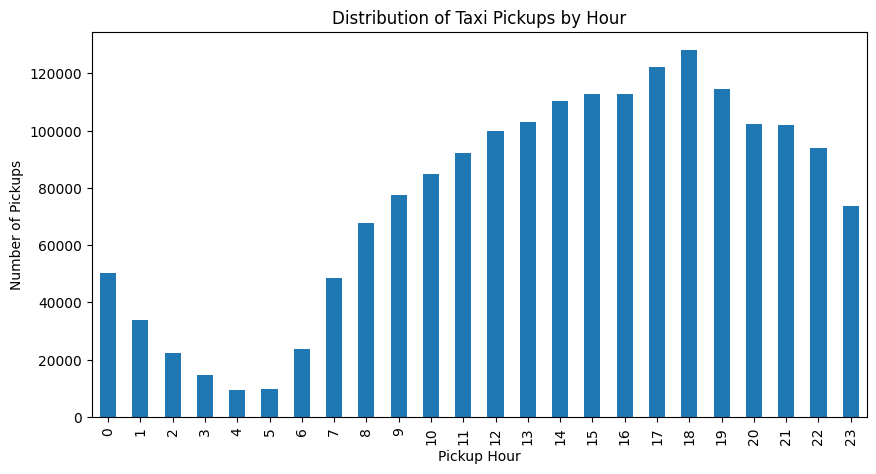

In [9]:
# Find and show the hourly trends in taxi pickups

hourly_pickups = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
hourly_pickups.plot(kind='bar')

plt.title('Distribution of Taxi Pickups by Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Pickups')
plt.xticks(range(24))

plt.show()


In [10]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_pickups = df['pickup_day'].value_counts().reindex(day_order)

daily_pickups

,count
pickup_day,
Monday,225748
Tuesday,263171
Wednesday,278795
Thursday,284405
Friday,268761
Saturday,263153
Sunday,226833


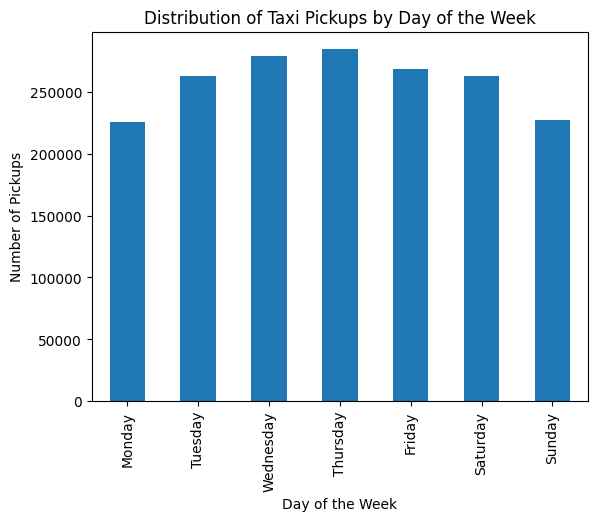

In [11]:
daily_pickups.plot(kind='bar')
plt.title('Distribution of Taxi Pickups by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.show()

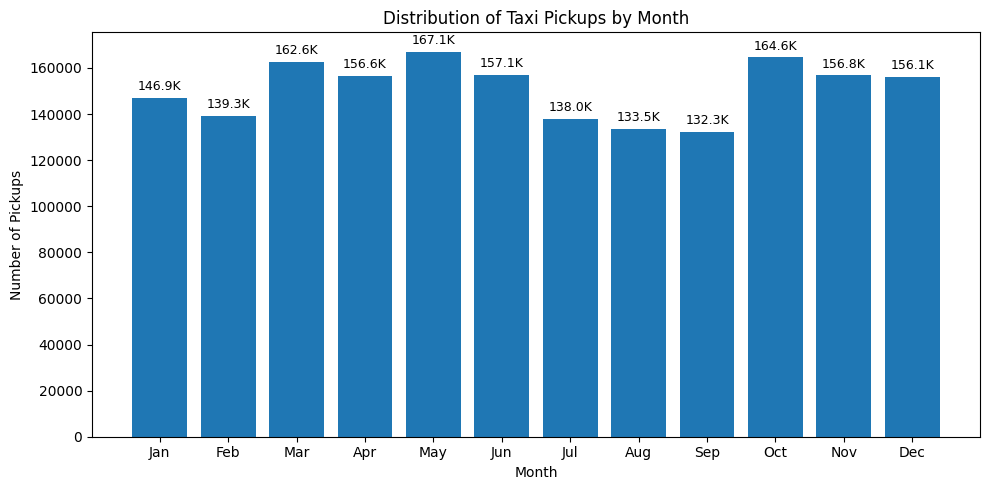

In [12]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

monthly_pickups = df['pickup_month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

bars = plt.bar(range(12), monthly_pickups.values)

plt.title('Distribution of Taxi Pickups by Month')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')

plt.xticks(
    range(12),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=0
)

# Add values on top of bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2000,
        f'{value/1000:.1f}K',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()



##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [13]:
# Analyse the above parameters
df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe()


,fare_amount,tip_amount,total_amount,trip_distance
count,1.810866e+06,1.810866e+06,1.810866e+06,1.810866e+06
mean,1.894687e+01,3.479562e+00,2.791045e+01,3.214015e+00
std,1.614684e+01,3.833215e+00,2.057404e+01,3.950045e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.300000e+00,1.000000e+00,1.595000e+01,1.040000e+00
50%,1.350000e+01,2.850000e+00,2.100000e+01,1.760000e+00
75%,2.120000e+01,4.400000e+00,3.020000e+01,3.270000e+00
max,3.000000e+02,2.230800e+02,4.020000e+02,1.999000e+01


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [14]:
# Create a df with non zero entries for the selected parameters.
df_nonzero = df[
    (df['fare_amount'] > 0) &
    (df['tip_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

df_nonzero.shape

(1398405, 23)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

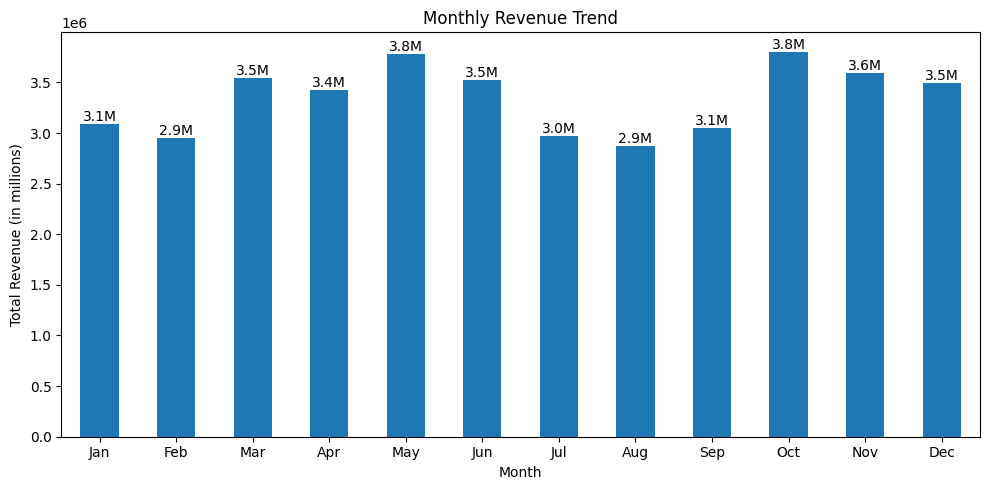

In [15]:
# Group data by month and analyse monthly revenue

monthly_revenue = df_nonzero.groupby('pickup_month')['total_amount'].sum()

ax = monthly_revenue.plot(kind='bar', figsize=(10, 5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (in millions)')
plt.xticks(
    range(12),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=0
)

for i, value in enumerate(monthly_revenue):
    ax.text(i, value, f'{value/1e6:.1f}M',
            ha='center', va='bottom')

plt.tight_layout()

plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [16]:
# Calculate proportion of each quarter


df_nonzero['quarter'] = ((df_nonzero['pickup_month'] - 1) // 3) + 1
quarterly_revenue = df_nonzero.groupby('quarter')['total_amount'].sum()

annual_revenue = quarterly_revenue.sum()

quarterly_proportion = (quarterly_revenue / annual_revenue) * 100

quarterly_proportion

,total_amount
quarter,
1,23.888844
2,26.751275
3,22.197230
4,27.162651


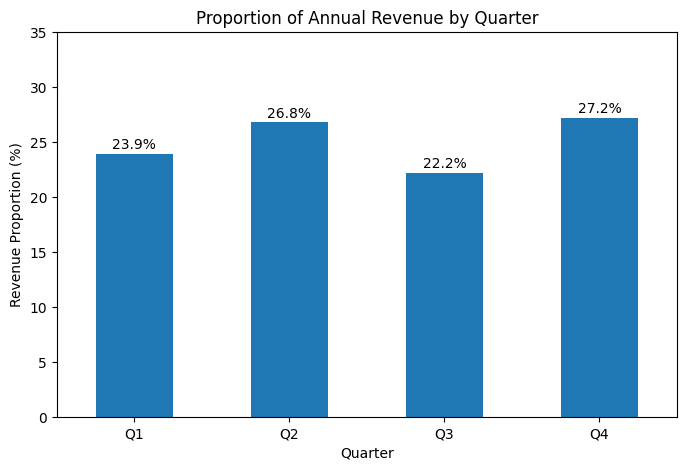

In [17]:
# Show the proportion of each quarter of the year in the revenue
ax = quarterly_proportion.plot(kind='bar', figsize=(8, 5))

plt.title('Proportion of Annual Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Revenue Proportion (%)')
plt.xticks(
    range(4),
    ['Q1', 'Q2', 'Q3', 'Q4'],
    rotation=0
)

plt.ylim(0, 35)

# Show percentage on top of each bar
for i, value in enumerate(quarterly_proportion):
    ax.text(
        i, value + 0.5,
        f'{value:.1f}%',
        ha='center'
    )

plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

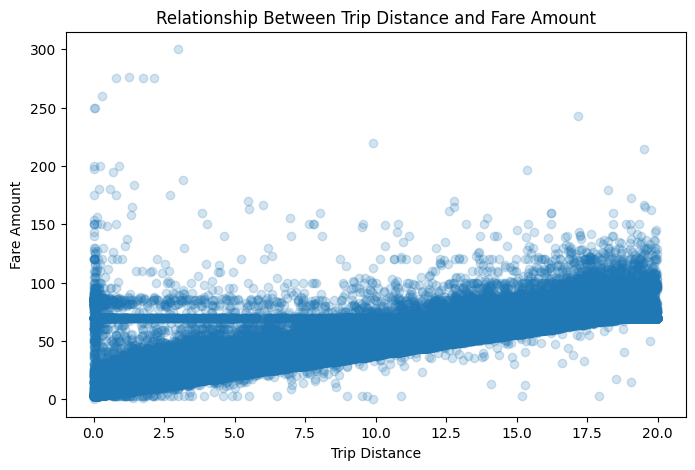

In [18]:
# Show how trip fare is affected by distance

plt.figure(figsize=(8, 5))

plt.scatter(
    df_nonzero['trip_distance'],
    df_nonzero['fare_amount'],
    alpha=0.2
)

plt.title('Relationship Between Trip Distance and Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')

plt.show()


In [19]:
#  correlation value for Trip Distance and Fare Amount

correlation = df_nonzero['trip_distance'].corr(
    df_nonzero['fare_amount']
)

print("Correlation between trip distance and fare amount:", correlation)

Correlation between trip distance and fare amount: 0.9513801442334425


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [20]:
# Show relationship between fare and trip duration
# Calculate trip duration in minutes

df_nonzero['trip_duration'] = (
    df_nonzero['tpep_dropoff_datetime'] -
    df_nonzero['tpep_pickup_datetime']
).dt.total_seconds() / 60

df_nonzero['trip_duration'].describe()


,trip_duration
count,1.398405e+06
mean,1.647151e+01
std,3.320402e+01
min,-5.430000e+01
25%,7.733333e+00
50%,1.251667e+01
75%,2.000000e+01
max,1.522100e+03


In [21]:
# Identify how many negative trip_duration
negative_duration = (df_nonzero['trip_duration'] < 0).sum()

print("Negative trip durations:", negative_duration)

Negative trip durations: 32


In [22]:
# Remove records with invalid negative trip duration

df_nonzero = df_nonzero[
    df_nonzero['trip_duration'] >= 0
].copy()

print("Shape after removing negative durations:", df_nonzero.shape)

Shape after removing negative durations: (1398373, 25)


In [23]:
# Check unusually long trip durations

long_duration = df_nonzero[df_nonzero['trip_duration'] > 180]

print("Trips longer than 3 hours:", long_duration.shape[0])

Trips longer than 3 hours: 800


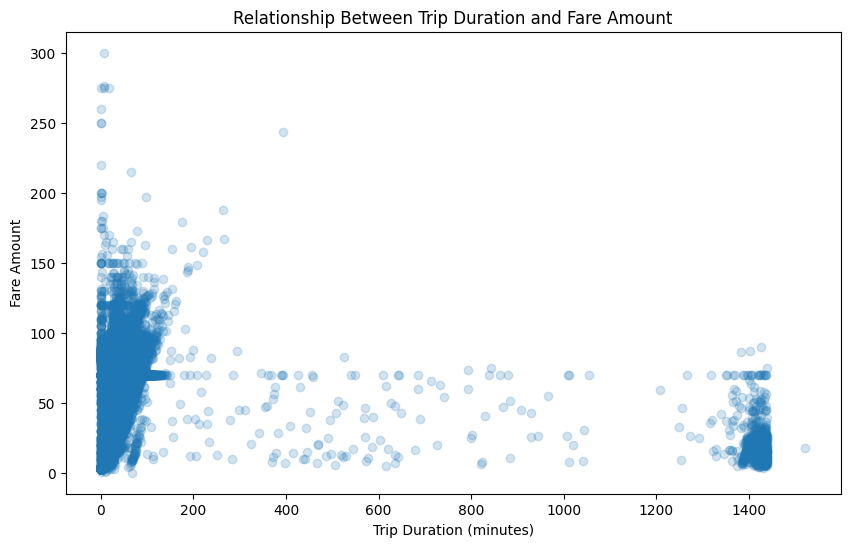

In [24]:
# Show relationship between fare and trip duration

plt.figure(figsize=(10, 6))

plt.scatter(
    df_nonzero['trip_duration'],
    df_nonzero['fare_amount'],
    alpha=0.2
)

plt.title('Relationship Between Trip Duration and Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')

plt.show()

In [25]:
# Correlation between trip duration and fare amount

duration_fare_corr = df_nonzero['trip_duration'].corr(
    df_nonzero['fare_amount']
)

print("Correlation between trip duration and fare amount:",
      duration_fare_corr)

Correlation between trip duration and fare amount: 0.3196364217672427


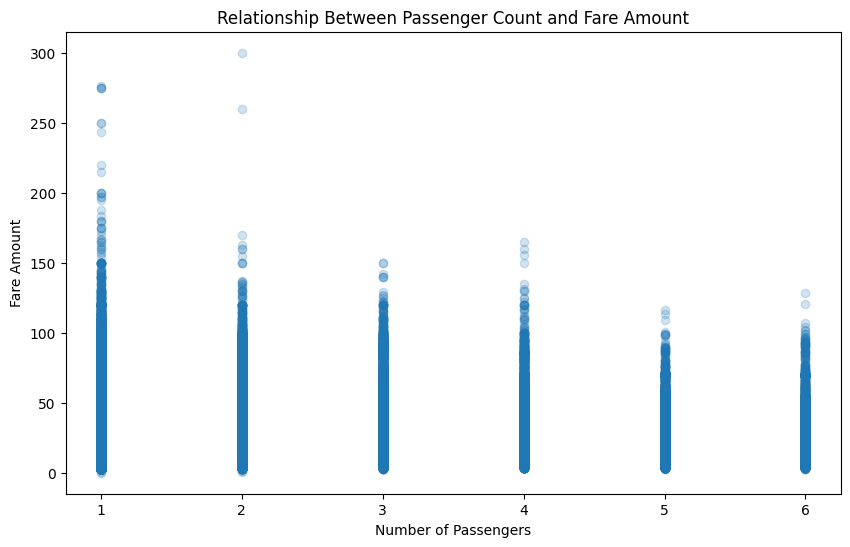

In [26]:
# Show relationship between fare and number of passengers


plt.figure(figsize=(10, 6))

plt.scatter(
    df_nonzero['passenger_count'],
    df_nonzero['fare_amount'],
    alpha=0.2
)

plt.title('Relationship Between Passenger Count and Fare Amount')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount')

plt.show()


In [27]:
# Correlation between passenger count and fare amount

passenger_fare_corr = df_nonzero['passenger_count'].corr(
    df_nonzero['fare_amount']
)

print(
    "Correlation between passenger count and fare amount:",
    passenger_fare_corr
)

Correlation between passenger count and fare amount: 0.036738401554706195


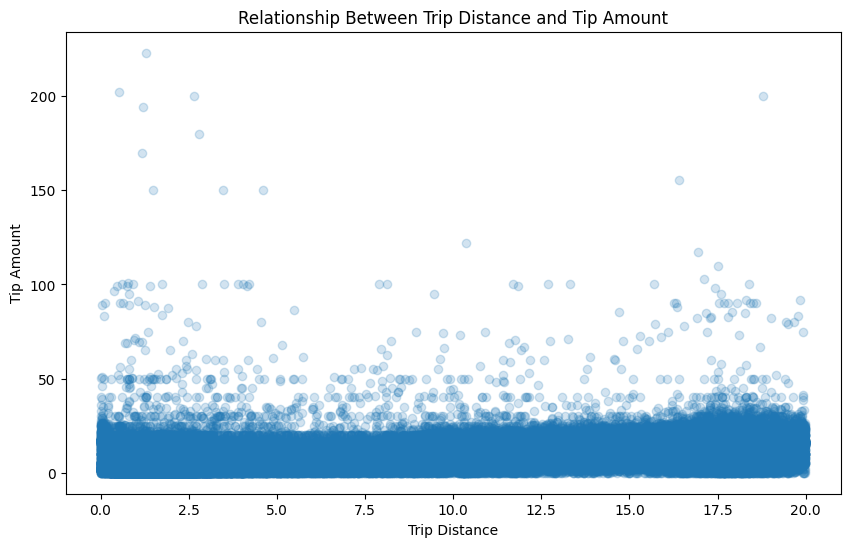

In [28]:
# Show relationship between tip amount and trip distance

plt.figure(figsize=(10, 6))

plt.scatter(
    df_nonzero['trip_distance'],
    df_nonzero['tip_amount'],
    alpha=0.2
)

plt.title('Relationship Between Trip Distance and Tip Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')

plt.show()




In [29]:
# Correlation between trip distance and tip amount

tip_distance_corr = df_nonzero['trip_distance'].corr(
    df_nonzero['tip_amount']
)

print(
    "Correlation between trip distance and tip amount:",
    tip_distance_corr
)

Correlation between trip distance and tip amount: 0.7951123302058496


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

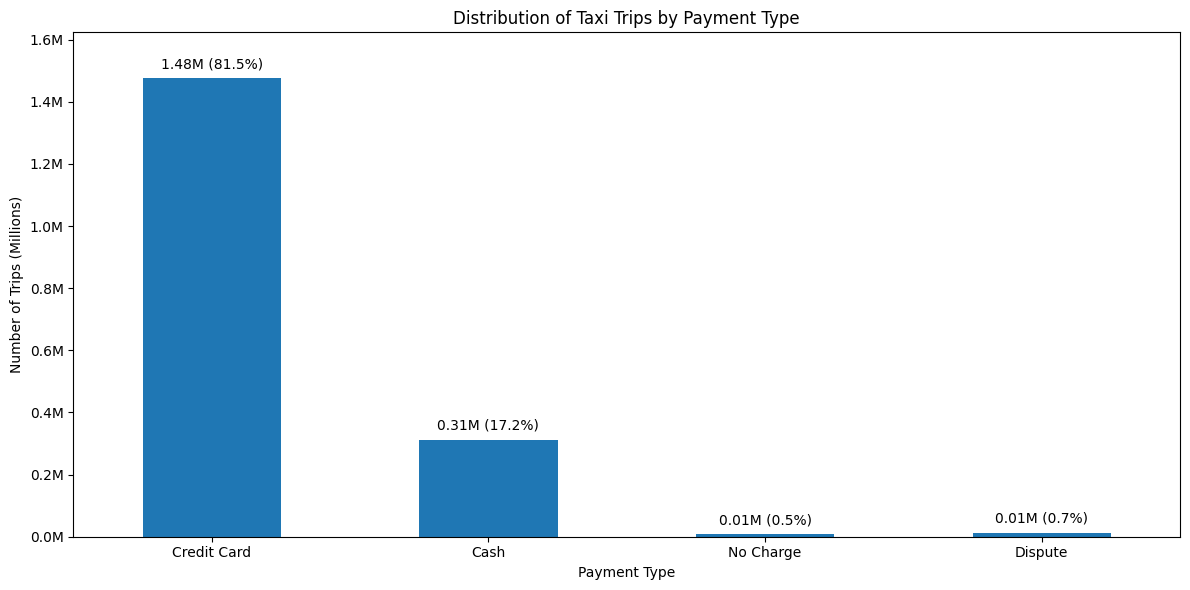

In [38]:
# Analyse the distribution of different payment types (payment_type).

ax = payment_counts.plot(kind='bar', figsize=(12, 6))

plt.title('Distribution of Taxi Trips by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips (Millions)')
plt.xticks(rotation=0)
# Show y-axis in millions
ax.set_yticklabels([f'{x/1e6:.1f}M' for x in ax.get_yticks()])

# Add count and percentage above each bar
for i, value in enumerate(payment_counts):
    percentage = payment_percentage.iloc[i]

    ax.text(
    i,
    value + payment_counts.max() * 0.015,
    f'{value/1e6:.2f}M ({percentage:.1f}%)',
    ha='center',
    va='bottom'
)

# Add some space above the bars
plt.ylim(0, payment_counts.max() * 1.10)

plt.tight_layout()
plt.show()


In [33]:
# Calculate percentage of each payment type

payment_percentage = (payment_counts / payment_counts.sum()) * 100

payment_percentage

,count
payment_type,
Credit Card,81.523426
Cash,17.242027
No Charge,0.491698
Dispute,0.742849


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [41]:
import geopandas as gpd


# Read the shapefile using geopandas
# zones = # read the .shp file using gpd
# zones.head()

import os

taxi_zones_folder = '/content/drive/MyDrive/IIITB/EDA Assignment/683eb526-56d0-483e-b940-287fbdee518c-APAGAI-Assignment-EDA/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/working_copy/taxi_zones'

zones = gpd.read_file(taxi_zones_folder + '/taxi_zones.shp')

zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [42]:
print("Shape of taxi zones:", zones.shape)
print("Number of zones:", zones['LocationID'].nunique())

Shape of taxi zones: (263, 7)
Number of zones: 260


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

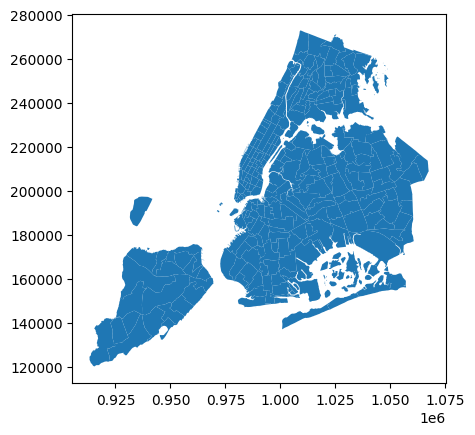

In [43]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID
df_geo = df.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df_geo.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee,pickup_day,pickup_month,LocationID,zone,borough
0,1,2023-03-01 00:06:18,2023-03-01 00:21:33,1.0,7.90,1.0,N,138,236,1,...,58.55,2.5,2023-03-01,0,1.25,Wednesday,3,138.0,LaGuardia Airport,Queens
1,2,2023-03-01 00:40:10,2023-03-01 00:45:44,1.0,1.55,1.0,N,113,164,1,...,16.32,2.5,2023-03-01,0,0.00,Wednesday,3,113.0,Greenwich Village North,Manhattan
2,2,2023-03-01 00:08:41,2023-03-01 00:12:28,4.0,0.73,1.0,N,238,166,1,...,10.80,0.0,2023-03-01,0,0.00,Wednesday,3,238.0,Upper West Side North,Manhattan
3,1,2023-03-01 00:37:43,2023-03-01 00:55:51,1.0,4.60,1.0,N,249,262,1,...,48.30,2.5,2023-03-01,0,0.00,Wednesday,3,249.0,West Village,Manhattan
4,2,2023-03-01 00:08:01,2023-03-01 00:14:41,1.0,1.33,1.0,N,249,68,1,...,16.32,2.5,2023-03-01,0,0.00,Wednesday,3,249.0,West Village,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [47]:
# Group data by location and calculate the number of trips

trips_per_location = (
    df_geo.groupby('PULocationID')
          .size()
          .reset_index(name='trip_count')
          .sort_values('trip_count', ascending=False)
)

trips_per_location

,PULocationID,trip_count
229,237,86797
154,161,85756
125,132,81548
228,236,77445
155,162,65513
...,...,...
82,84,1
55,57,1
165,172,1
213,221,1


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [48]:
# Merge trip counts back to the zones GeoDataFrame

# Merge trip counts with the taxi zones
zones_with_trips = zones.merge(
    trips_per_location,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

zones_with_trips.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,211.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,39.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1859.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,11.0


In [49]:
# Remove the duplicate location ID column
zones_with_trips.drop(columns='PULocationID', inplace=True)

zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",211.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",39.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1859.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",11.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

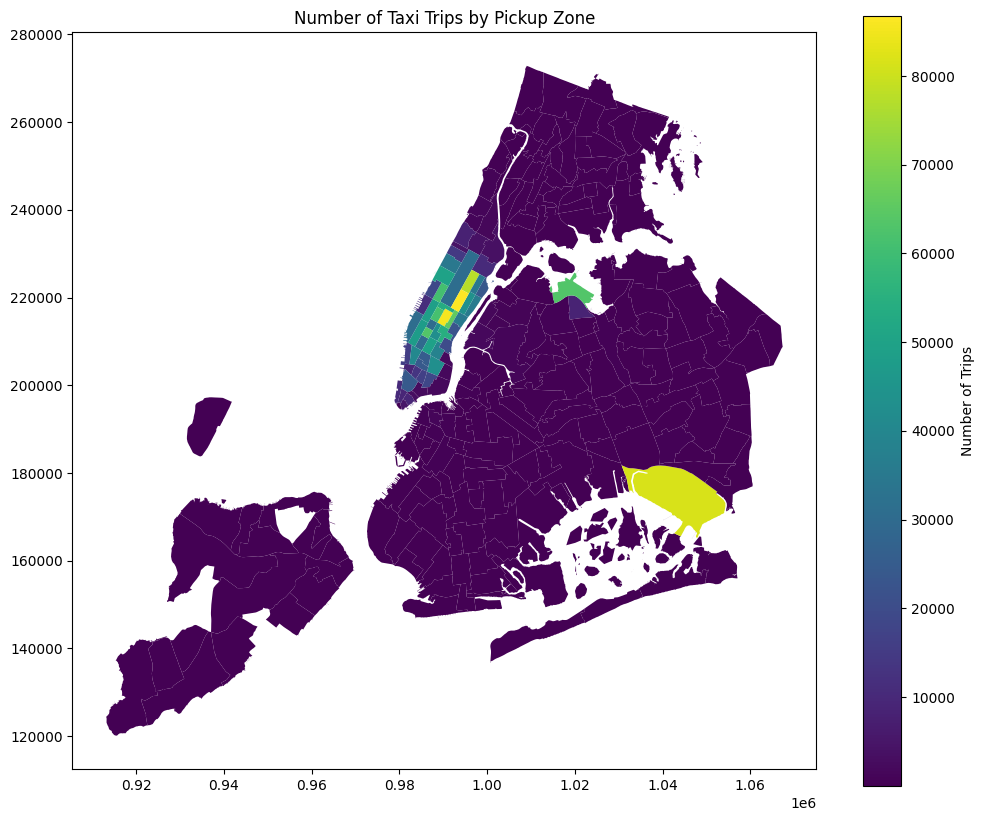

In [51]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot a color-coded map showing zone-wise trips

zones_with_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'vertical'
    }
)

plt.title('Number of Taxi Trips by Pickup Zone')
plt.show()


In [52]:
# can you try displaying the zones DF sorted by the number of trips?

# Display zones sorted by number of trips
zones_sorted = zones_with_trips.sort_values(by='trip_count',ascending=False)

zones_sorted[['LocationID', 'zone', 'borough', 'trip_count']].head(20)

,LocationID,zone,borough,trip_count
236,237,Upper East Side South,Manhattan,86797.0
160,161,Midtown Center,Manhattan,85756.0
131,132,JFK Airport,Queens,81548.0
235,236,Upper East Side North,Manhattan,77445.0
161,162,Midtown East,Manhattan,65513.0
185,186,Penn Station/Madison Sq West,Manhattan,63401.0
137,138,LaGuardia Airport,Queens,63386.0
229,230,Times Sq/Theatre District,Manhattan,61065.0
141,142,Lincoln Square East,Manhattan,60709.0
169,170,Murray Hill,Manhattan,54413.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

**1)Busiest Hours, days, and Months**

Taxi demand varies significantly across hours of the day, indicating clear differences between low- and high-demand periods.
Trip activity is concentrated around peak travel periods, reflecting commuting, business and leisure travel patterns.
The monthly analysis also shows variation in taxi demand across the year, indicating that taxi utilization is influenced by seasonal and temporal factors.

**2)Trends in revenue collected**

Revenue generated from taxi trips varies with the overall trip activity.
Periods with higher trip volumes generally contribute to higher total fare/revenue collection.
The analysis of fare_amount and total_amount helps identify the financial contribution of taxi trips across different periods.

**3)Trends in quarterly revenue**

Quarterly analysis provides a broader view of revenue performance by reducing the effect of individual monthly fluctuations.
Comparing quarters helps identify periods of relatively higher and lower revenue generation during the year.
This can be useful for understanding overall business performance and planning capacity around higher-demand periods.

**4)How fare depends on trip distance, trip duration and passenger counts**

Trip distance and fare amount show a positive relationship(0.95), as longer trips generally involve higher fares.
The correlation between trip duration and fare amount is approximately 0.32, indicating a relatively weak-to-moderate relationship.
This suggests that a longer trip duration does not necessarily result in a proportionally higher fare. For example, additional duration may result from traffic congestion or delays rather than additional distance travelled.
Passenger count has almost no linear relationship with fare amount, with a correlation of approximately 0.037.
Therefore, the number of passengers in a taxi appears to have little influence on the fare charged for a trip.

**5)How tip amount depends on trip distance**

The analysis shows a strong positive relationship between trip distance and tip amount.

The correlation between trip distance and tip amount is approximately 0.80.
Longer trips generally tend to generate higher tips.
However, the scatter plot also shows considerable variation, indicating that distance is not the only factor influencing tip amount.

**6)Busiest Zones**
The geographical analysis shows that taxi demand is highly concentrated in specific pickup zones.

The highest-volume zones in our sampled data include:

Upper East Side South – 86,797 trips,
Midtown Center – 85,756 trips,
JFK Airport – 81,548 trips,
Upper East Side North – 77,445 trips,
Midtown East – 65,513 trips.

Other high-volume locations include Penn Station/Madison Sq West, LaGuardia Airport, Times Sq/Theatre District, Lincoln Square East and Murray Hill.


You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [62]:
# Find routes which have the slowest speeds at different times of the day

# Start with the filtered route-hour data
slow_routes = route_hour[
    (route_hour['avg_distance'] >= 0.5) &
    (route_hour['trip_count'] >= 20)
].copy()

# Sort by speed to identify slow routes
slow_routes = slow_routes.sort_values(
    by='avg_speed_mph',
    ascending=True
)

# Add pickup zone name
pickup_zones = zones[['LocationID', 'zone', 'borough']].rename(
    columns={
        'LocationID': 'PULocationID',
        'zone': 'pickup_zone',
        'borough': 'pickup_borough'
    }
)

slow_routes = slow_routes.merge(
    pickup_zones,
    on='PULocationID',
    how='left'
)

# Add drop-off zone name
dropoff_zones = zones[['LocationID', 'zone', 'borough']].rename(
    columns={
        'LocationID': 'DOLocationID',
        'zone': 'dropoff_zone',
        'borough': 'dropoff_borough'
    }
)

slow_routes = slow_routes.merge(
    dropoff_zones,
    on='DOLocationID',
    how='left'
)

# Display the most relevant columns
slow_routes[
    [
        'PULocationID',
        'pickup_zone',
        'DOLocationID',
        'dropoff_zone',
        'pickup_hour',
        'avg_distance',
        'avg_duration',
        'trip_count',
        'avg_speed_mph'
    ]
].head(20)

,PULocationID,pickup_zone,DOLocationID,dropoff_zone,pickup_hour,avg_distance,avg_duration,trip_count,avg_speed_mph
0,158,Meatpacking/West Village West,158,Meatpacking/West Village West,19,0.653810,73.400000,21,0.534449
1,158,Meatpacking/West Village West,158,Meatpacking/West Village West,22,0.505000,49.050000,22,0.617737
2,249,West Village,114,Greenwich Village South,3,0.774091,69.831818,22,0.665104
3,114,Greenwich Village South,113,Greenwich Village North,11,0.675185,57.491358,27,0.704647
4,233,UN/Turtle Bay South,229,Sutton Place/Turtle Bay North,23,0.736400,61.308000,25,0.720689
5,113,Greenwich Village North,234,Union Sq,1,1.010000,76.314167,20,0.794086
6,68,East Chelsea,68,East Chelsea,2,0.661250,47.614062,32,0.833262
7,48,Clinton East,230,Times Sq/Theatre District,14,0.765574,54.174863,61,0.847892
8,148,Lower East Side,232,Two Bridges/Seward Park,18,0.924400,64.337333,25,0.862081
9,164,Midtown South,100,Garment District,21,0.787188,51.182813,32,0.922795


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest hour: 18
Number of trips: 128061


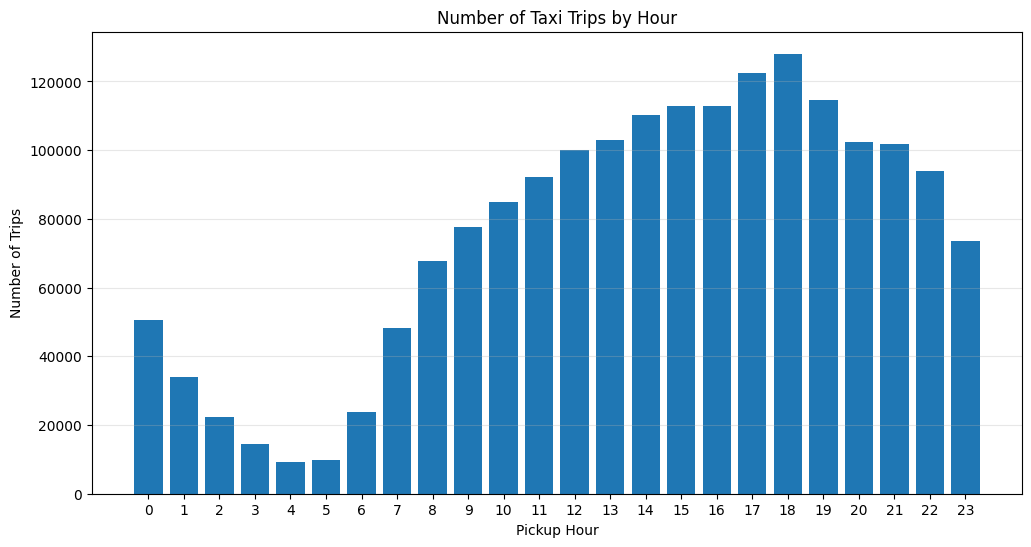

In [63]:
# Visualise the number of trips per hour and find the busiest hour

# Group trips by pickup hour
trips_per_hour = df_geo.groupby('pickup_hour').size()

# Find the busiest hour
busiest_hour = trips_per_hour.idxmax()
busiest_hour_trips = trips_per_hour.max()

print("Busiest hour:", busiest_hour)
print("Number of trips:", busiest_hour_trips)

# Plot number of trips by hour
plt.figure(figsize=(12, 6))

plt.bar(trips_per_hour.index, trips_per_hour.values)

plt.title('Number of Taxi Trips by Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [64]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

actual_trips_per_hour = trips_per_hour / sample_fraction

# Find the five busiest hours
five_busiest_hours = actual_trips_per_hour.sort_values(
    ascending=False
).head(5)

five_busiest_hours



,0
pickup_hour,
18,2561220.0
17,2447140.0
19,2293000.0
15,2258100.0
16,2256720.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

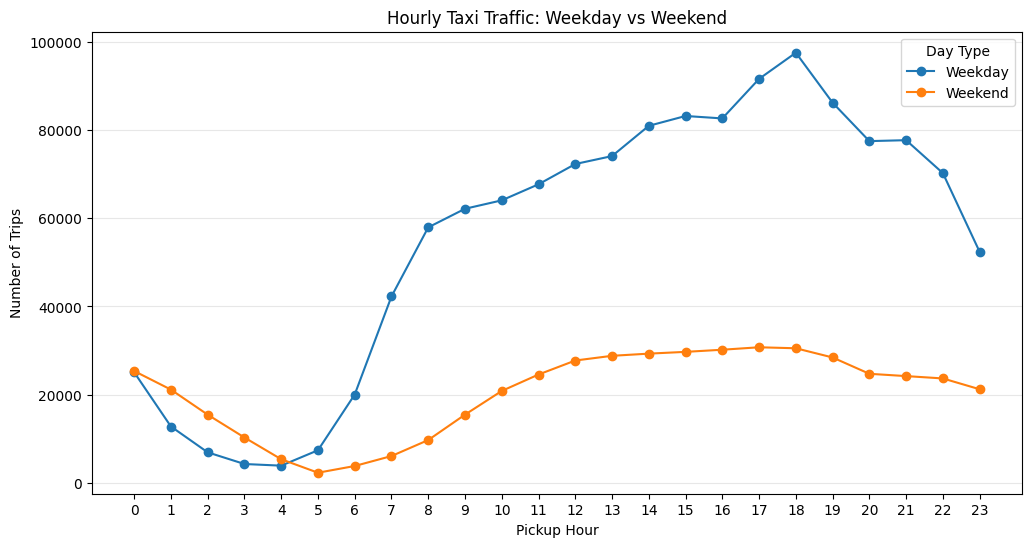

In [65]:
# Compare traffic trends for the week days and weekends

df_geo['day_type'] = df_geo['pickup_day'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

df_geo[['pickup_day', 'day_type']].drop_duplicates().sort_values('pickup_day')

# Calculate number of trips for each hour by weekday/weekend

hourly_day_type = (
    df_geo.groupby(['pickup_hour', 'day_type'])
    .size()
    .reset_index(name='trip_count')
)


# Reshape data for plotting
hourly_pivot = hourly_day_type.pivot(
    index='pickup_hour',
    columns='day_type',
    values='trip_count'
)

# Plot weekday vs weekend traffic
hourly_pivot.plot(
    kind='line',
    figsize=(12, 6),
    marker='o'
)

plt.title('Hourly Taxi Traffic: Weekday vs Weekend')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Day Type')

plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Weekday and weekend taxi demand show distinct hourly patterns. Weekday demand increases substantially from the morning and reaches its highest level around 18:00, indicating a strong evening peak. Weekend demand is lower overall and more evenly distributed across the daytime and evening hours. Both segments experience relatively low demand during the early-morning period. Identifying these busy and quiet periods can help optimize taxi availability, driver scheduling, vehicle positioning and utilization, while reducing idle capacity during low-demand hours.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [66]:
# Find top 10 pickup and dropoff zones
top_pickup_zones = (
    df_geo.groupby(['PULocationID', 'zone'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
    .head(10)
)

top_pickup_zones


,PULocationID,zone,trip_count
228,237,Upper East Side South,86797
153,161,Midtown Center,85756
124,132,JFK Airport,81548
227,236,Upper East Side North,77445
154,162,Midtown East,65513
177,186,Penn Station/Madison Sq West,63401
130,138,LaGuardia Airport,63386
221,230,Times Sq/Theatre District,61065
134,142,Lincoln Square East,60709
162,170,Murray Hill,54413


In [67]:
# Create a lookup table for drop-off zones
dropoff_zones = zones[['LocationID', 'zone']].copy()

# Rename columns for clarity
dropoff_zones.rename(
    columns={
        'LocationID': 'DOLocationID',
        'zone': 'dropoff_zone'
    },
    inplace=True
)

# Merge drop-off zone names with trip data
df_geo = df_geo.merge(
    dropoff_zones,
    on='DOLocationID',
    how='left'
)

# Find top 10 drop-off zones
top_dropoff_zones = (
    df_geo.groupby(['DOLocationID', 'dropoff_zone'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
    .head(10)
)

top_dropoff_zones

,DOLocationID,dropoff_zone,trip_count
228,236,Upper East Side North,81109
229,237,Upper East Side South,77291
154,161,Midtown Center,71517
222,230,Times Sq/Theatre District,56154
163,170,Murray Hill,54291
155,162,Midtown East,52188
135,142,Lincoln Square East,51061
231,239,Upper West Side South,50152
134,141,Lenox Hill West,48173
66,68,East Chelsea,46280


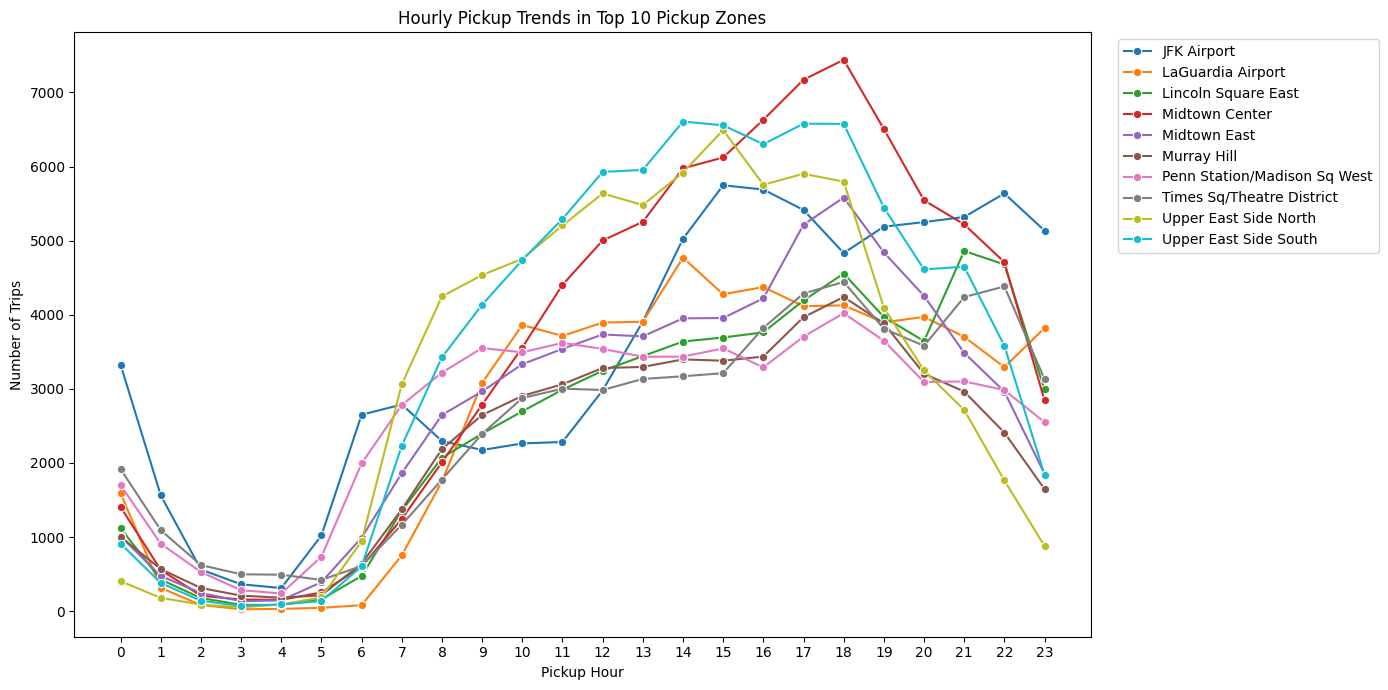

In [68]:
# Hourly pickup trends for the top 10 pickup zones

pickup_hourly = (
    df_geo[df_geo['PULocationID'].isin(top_pickup_zones['PULocationID'])]
    .groupby(['zone', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
)

pickup_hourly.head()

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=pickup_hourly,
    x='pickup_hour',
    y='trip_count',
    hue='zone',
    marker='o'
)

plt.title('Hourly Pickup Trends in Top 10 Pickup Zones')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

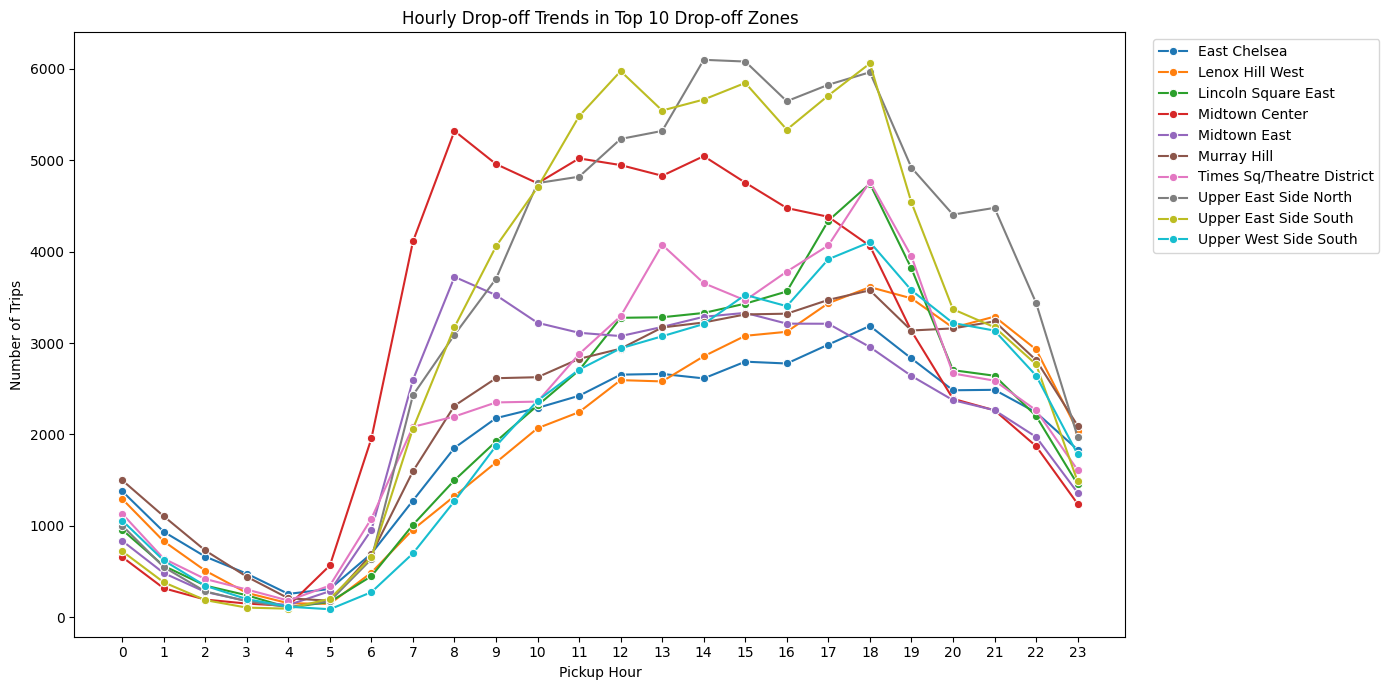

In [69]:
# Hourly drop-off trends for the top 10 drop-off zones

dropoff_hourly = (
    df_geo[df_geo['DOLocationID'].isin(top_dropoff_zones['DOLocationID'])]
    .groupby(['dropoff_zone', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
)

dropoff_hourly.head()

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=dropoff_hourly,
    x='pickup_hour',
    y='trip_count',
    hue='dropoff_zone',
    marker='o'
)

plt.title('Hourly Drop-off Trends in Top 10 Drop-off Zones')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [70]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Count pickups for each zone
pickup_counts = df_geo.groupby('PULocationID').size()

# Count drop-offs for each zone
dropoff_counts = df_geo.groupby('DOLocationID').size()

# Combine pickup and drop-off counts
zone_ratios = pd.DataFrame({
    'pickup_count': pickup_counts,
    'dropoff_count': dropoff_counts
}).fillna(0)

# Calculate pickup/drop-off ratio
zone_ratios['pickup_dropoff_ratio'] = (
    zone_ratios['pickup_count'] /
    zone_ratios['dropoff_count']
)

zone_ratios.head()

,pickup_count,dropoff_count,pickup_dropoff_ratio
1,211.0,4270.0,0.049415
2,2.0,4.0,0.500000
3,39.0,143.0,0.272727
4,1860.0,6829.0,0.272368
5,11.0,20.0,0.550000


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [74]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Define night hours: 11 PM to 5 AM
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Filter trips occurring during night hours
night_trips = df_geo[df_geo['pickup_hour'].isin(night_hours)]

print("Number of night-hour trips:", len(night_trips))

# Top 10 pickup zones during night hours
night_pickups = (
    night_trips.groupby('PULocationID')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

night_pickups_df = night_pickups.reset_index(
    name='night_pickups'
).merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

night_pickups_df[
    ['PULocationID', 'zone', 'borough', 'night_pickups']
]

# Top 10 drop-off zones during night hours
night_dropoffs = (
    night_trips.groupby('DOLocationID')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

night_dropoffs_df = night_dropoffs.reset_index(
    name='night_dropoffs'
).merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

night_dropoffs_df[
    ['DOLocationID', 'zone', 'borough', 'night_dropoffs']
]

print("Top 10 Pickup Zones during Night Hours")
print(night_pickups_df)

print("\nTop 10 Drop-off Zones during Night Hours")
print(night_dropoffs_df)


Number of night-hour trips: 214182
Top 10 Pickup Zones during Night Hours
   PULocationID  night_pickups  LocationID                          zone  \
0            79          15544          79                  East Village   
1           249          12464         249                  West Village   
2           132          12283         132                   JFK Airport   
3            48          10450          48                  Clinton East   
4           148           9627         148               Lower East Side   
5           114           8742         114       Greenwich Village South   
6           230           8176         230     Times Sq/Theatre District   
7           186           6948         186  Penn Station/Madison Sq West   
8           164           6124         164                 Midtown South   
9            68           6038          68                  East Chelsea   

     borough  
0  Manhattan  
1  Manhattan  
2     Queens  
3  Manhattan  
4  Manhattan  

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [75]:
# Filter for night hours (11 PM to 5 AM)

# Define night hours: 11 PM to 5 AM
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Calculate revenue during night hours
night_revenue = df_geo.loc[
    df_geo['pickup_hour'].isin(night_hours),
    'total_amount'
].sum()

# Calculate revenue during daytime hours
day_revenue = df_geo.loc[
    ~df_geo['pickup_hour'].isin(night_hours),
    'total_amount'
].sum()

# Total revenue
total_revenue = night_revenue + day_revenue

print("Night revenue:", night_revenue)
print("Day revenue:", day_revenue)
print("Total revenue:", total_revenue)

# Calculate revenue share
night_revenue_share = (night_revenue / total_revenue) * 100
day_revenue_share = (day_revenue / total_revenue) * 100

print(f"Night revenue share: {night_revenue_share:.2f}%")
print(f"Day revenue share: {day_revenue_share:.2f}%")

Night revenue: 6068001.629999999
Day revenue: 44501841.759999976
Total revenue: 50569843.38999997
Night revenue share: 12.00%
Day revenue share: 88.00%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [76]:
# Analyse the fare per mile per passenger for different passenger counts

# Calculate fare per mile, avoiding division by zero. For every taxi trip, if the trip distance is greater than zero, calculate fare per mile. Otherwise, leave the value as missing (NaN).
df_geo['fare_per_mile'] = np.where(
    df_geo['trip_distance'] > 0,
    df_geo['fare_amount'] / df_geo['trip_distance'],
    np.nan
)

# Calculate average fare per mile for each passenger count
fare_per_passenger = (
    df_geo.groupby('passenger_count')['fare_per_mile']
    .mean()
    .reset_index()
)

# Calculate fare per mile per passenger
fare_per_passenger['fare_per_mile_per_passenger'] = (
    fare_per_passenger['fare_per_mile'] /
    fare_per_passenger['passenger_count']
)

fare_per_passenger



,passenger_count,fare_per_mile,fare_per_mile_per_passenger
0,1.0,10.931512,10.931512
1,2.0,13.028604,6.514302
2,3.0,11.850248,3.950083
3,4.0,17.678670,4.419668
4,5.0,8.597699,1.719540
5,6.0,8.151362,1.358560


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [81]:
# Compare the average fare per mile for different days and for different times of the day

# Create day of week from pickup date/time
df_geo['pickup_day'] = df_geo['tpep_pickup_datetime'].dt.day_name()

df_geo[['tpep_pickup_datetime', 'pickup_day']].head()

# Average fare per mile by hour
fare_per_mile_hour = (
    df_geo.groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index()
)


# Average fare per mile by day of the week
fare_per_mile_day = (
    df_geo.groupby('pickup_day')['fare_per_mile']
    .mean()
    .reset_index()
)

fare_per_mile_day


,pickup_day,fare_per_mile
0,Friday,10.977825
1,Monday,11.093835
2,Saturday,10.999097
3,Sunday,12.653602
4,Thursday,11.349857
5,Tuesday,11.471278
6,Wednesday,11.184788


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

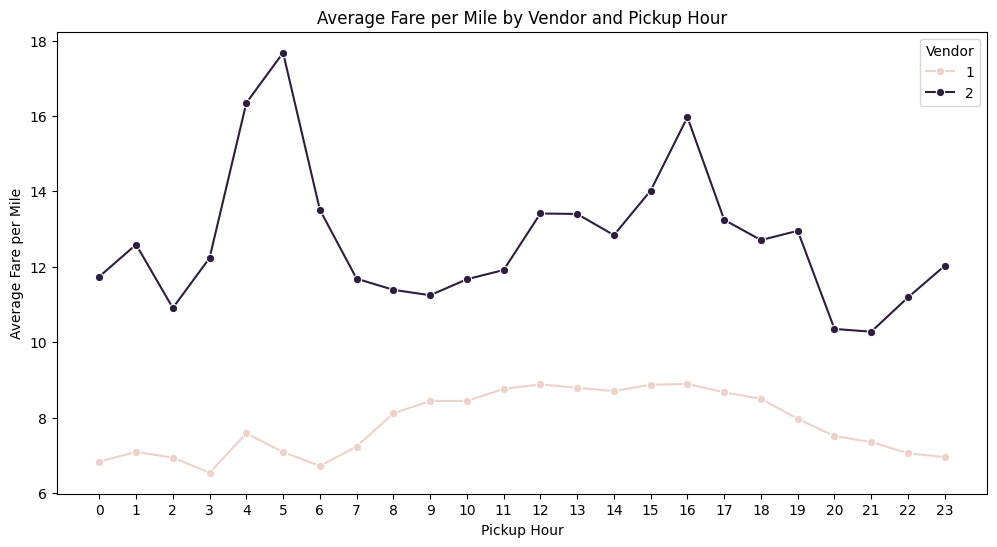

In [82]:
# Compare fare per mile for different vendors

vendor_hourly_fare = (
    df_geo.groupby(['pickup_hour', 'VendorID'])['fare_per_mile']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=vendor_hourly_fare,
    x='pickup_hour',
    y='fare_per_mile',
    hue='VendorID',
    marker='o'
)

plt.title('Average Fare per Mile by Vendor and Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare per Mile')
plt.xticks(range(24))
plt.legend(title='Vendor')
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [84]:
# Defining distance tiers

# Define distance tiers

conditions = [
    df_geo['trip_distance'] <= 2,
    (df_geo['trip_distance'] > 2) & (df_geo['trip_distance'] <= 5),
    df_geo['trip_distance'] > 5
]

choices = [
    'Up to 2 miles',
    '2 to 5 miles',
    'More than 5 miles'
]

df_geo['distance_tier'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

#df_geo[['trip_distance', 'distance_tier']].head(10)

# Compare average fare per mile by vendor and distance tier

tier_vendor_fare = (
    df_geo.groupby(['distance_tier', 'VendorID'])['fare_per_mile']
    .mean()
    .reset_index()
)

tier_vendor_fare


,distance_tier,VendorID,fare_per_mile
0,2 to 5 miles,1,6.379649
1,2 to 5 miles,2,6.548366
2,More than 5 miles,1,4.472353
3,More than 5 miles,2,4.558338
4,Up to 2 miles,1,9.924581
5,Up to 2 miles,2,17.929445


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [85]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Calculate tip percentage
df_geo['tip_percentage'] = np.where(
    df_geo['fare_amount'] > 0,
    (df_geo['tip_amount'] / df_geo['fare_amount']) * 100,
    np.nan
)

df_geo[['fare_amount', 'tip_amount', 'tip_percentage']].head()


,fare_amount,tip_amount,tip_percentage
0,31.0,9.75,31.451613
1,8.6,2.72,31.627907
2,6.5,1.80,27.692308
3,23.3,20.00,85.836910
4,8.6,2.72,31.627907


In [86]:
# Create distance bands
conditions = [
    df_geo['trip_distance'] <= 2,
    (df_geo['trip_distance'] > 2) & (df_geo['trip_distance'] <= 5),
    (df_geo['trip_distance'] > 5)
]

choices = [
    'Up to 2 miles',
    '2 to 5 miles',
    'More than 5 miles'
]

df_geo['distance_tier'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

tip_by_distance = (
    df_geo.groupby('distance_tier')['tip_percentage']
    .mean()
    .reset_index()
)

tip_by_distance

,distance_tier,tip_percentage
0,2 to 5 miles,18.762725
1,More than 5 miles,17.873166
2,Up to 2 miles,23.959171


In [87]:
tip_by_passengers = (
    df_geo.groupby('passenger_count')['tip_percentage']
    .mean()
    .reset_index()
)

tip_by_passengers

,passenger_count,tip_percentage
0,1.0,22.023038
1,2.0,20.563970
2,3.0,19.054601
3,4.0,17.462069
4,5.0,20.566745
5,6.0,20.640025


In [88]:
tip_by_hour = (
    df_geo.groupby('pickup_hour')['tip_percentage']
    .mean()
    .reset_index()
)

tip_by_hour

,pickup_hour,tip_percentage
0,0,26.761588
1,1,21.293125
2,2,20.840303
3,3,20.648071
4,4,19.097600
5,5,17.478127
6,6,18.369885
7,7,19.643712
8,8,20.033449
9,9,19.738376


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [91]:
# See how passenger count varies across hours and days

# Total passengers by pickup hour
passengers_by_hour = (
    df_geo.groupby('pickup_hour')['passenger_count']
    .sum()
    .reset_index()
)

passengers_by_hour


,pickup_hour,passenger_count
0,0,72115.0
1,1,48639.0
2,2,32483.0
3,3,21255.0
4,4,13027.0
5,5,12542.0
6,6,29881.0
7,7,61615.0
8,8,87421.0
9,9,102181.0


In [92]:
# Average passenger count by day of week

# Total passengers by day of week
passengers_by_day = (
    df_geo.groupby('pickup_day')['passenger_count']
    .sum()
    .reset_index()
)

passengers_by_day

,pickup_day,passenger_count
0,Friday,376006.0
1,Monday,306804.0
2,Saturday,389381.0
3,Sunday,332099.0
4,Thursday,381668.0
5,Tuesday,350475.0
6,Wednesday,370374.0


In [95]:
# Average passengers per trip by hour
avg_passengers_by_hour = (
    df_geo.groupby('pickup_hour')['passenger_count']
    .mean()
    .reset_index()
)

print(avg_passengers_by_hour)

# Average passengers per trip by day
avg_passengers_by_day = (
    df_geo.groupby('pickup_day')['passenger_count']
    .mean()
    .reset_index()
)

print(avg_passengers_by_day)

    pickup_hour  passenger_count
0             0         1.428472
1             1         1.432202
2             2         1.448517
3             3         1.455623
4             4         1.401054
5             5         1.288473
6             6         1.250094
7             7         1.273327
8             8         1.291452
9             9         1.315918
10           10         1.353049
11           11         1.363422
12           12         1.380291
13           13         1.383027
14           14         1.389273
15           15         1.407396
16           16         1.404503
17           17         1.391390
18           18         1.377464
19           19         1.389816
20           20         1.398183
21           21         1.426447
22           22         1.429465
23           23         1.422663
  pickup_day  passenger_count
0     Friday         1.398582
1     Monday         1.358568
2   Saturday         1.479254
3     Sunday         1.463410
4   Thursday         1.34

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [98]:
# How does passenger count vary across zones

# Total passenger count by pickup zone

passengers_by_zone = (
    df_geo.groupby('PULocationID')['passenger_count']
    .sum()
    .reset_index()
    .sort_values('passenger_count', ascending=False)
)


passengers_by_zone = passengers_by_zone.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

passengers_by_zone[
    ['PULocationID', 'zone', 'borough', 'passenger_count']
].head(10)

,PULocationID,zone,borough,passenger_count
0,132,JFK Airport,Queens,122224.0
1,161,Midtown Center,Manhattan,119345.0
2,237,Upper East Side South,Manhattan,116425.0
3,236,Upper East Side North,Manhattan,104079.0
4,230,Times Sq/Theatre District,Manhattan,91229.0
5,162,Midtown East,Manhattan,87449.0
6,138,LaGuardia Airport,Queens,86654.0
7,186,Penn Station/Madison Sq West,Manhattan,85636.0
8,142,Lincoln Square East,Manhattan,84152.0
9,163,Midtown North,Manhattan,74817.0


In [100]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Calculate average passenger count for each pickup zone
avg_passengers_zone = (
    df_geo.groupby('PULocationID')['passenger_count']
    .mean()
)

# Create a new column in zones_with_trips
zones_with_trips['avg_passenger_count'] = (
    zones_with_trips['LocationID']
    .map(avg_passengers_zone)
)

zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count,passenger_count,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",211.0,1.606635,1.606635
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,1.000000,1.000000
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",39.0,1.025641,1.025641
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1859.0,1.430645,1.430645
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",11.0,1.000000,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [101]:
# How often is each surcharge applied?

# Check how frequently extra charges are applied

extra_summary = (
    df_geo['extra']
    .value_counts()
    .sort_index()
)

extra_summary

,count
extra,
0.00,685783
0.01,1
0.03,1
0.19,1
0.25,2
0.50,21
0.70,2
0.75,10
1.00,359502


In [102]:
# Percentage of trips with an extra charge

extra_applied = (df_geo['extra'] > 0).sum()
total_trips = len(df_geo)

extra_percentage = (extra_applied / total_trips) * 100

print("Trips with extra charge:", extra_applied)
print("Percentage of trips with extra charge:", round(extra_percentage, 2), "%")

Trips with extra charge: 1125734
Percentage of trips with extra charge: 62.14 %


In [103]:
# Extra charges by pickup hour

extra_by_hour = (
    df_geo.groupby('pickup_hour')['extra']
    .apply(lambda x: (x > 0).sum())
    .reset_index(name='extra_charge_trips')
    .sort_values('extra_charge_trips', ascending=False)
)

extra_by_hour.head(10)

,pickup_hour,extra_charge_trips
18,18,103346
21,21,98897
20,20,97916
17,17,97616
19,19,91727
22,22,90983
16,16,85987
23,23,71112
0,0,48657
15,15,34631


In [104]:
# Extra charges by pickup zone

extra_by_zone = (
    df_geo.groupby('PULocationID')['extra']
    .apply(lambda x: (x > 0).sum())
    .reset_index(name='extra_charge_trips')
    .sort_values('extra_charge_trips', ascending=False)
)

extra_by_zone.head(10)

,PULocationID,extra_charge_trips
131,138,62641
154,161,55136
229,237,49964
125,132,41278
228,236,41230
155,162,40716
222,230,40635
135,142,38415
178,186,37312
156,163,34067


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Key Insights**
Taxi demand rises substantially during the daytime and peaks around 18:00.
Several routes show very low average speeds, indicating potential congestion or route inefficiencies.
Demand is concentrated in specific high-volume pickup zones.
Night-time demand remains significant, particularly in selected zones.

**Recommendations**

Increase taxi availability before and during the 17:00–19:00 peak period to match rising demand.
Pre-position vehicles near high-demand pickup zones such as Midtown, Upper East Side and major airports/stations before peak periods.
Use historical zone-hour demand patterns to dynamically reposition idle taxis rather than waiting for requests.
For consistently slow routes, consider alternative routing or dispatching vehicles from closer zones to reduce pickup and travel time.
Maintain targeted night-time availability in zones identified as having high overnight demand.

**Business objective**
Improve vehicle utilisation, reduce passenger waiting time and minimise supply-demand gaps.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**Key Insights**

1.Taxi activity is highly concentrated geographically rather than evenly distributed across all zones.

2.Manhattan's major commercial and transportation zones generate particularly high pickup volumes.

3.Airport zones such as JFK and LaGuardia are also among the important demand locations.

4.Demand patterns differ between weekdays, weekends and night hours.


**Recommendations**

Create zone-based demand clusters such as:
Manhattan commercial/business zones
Airport/transportation zones
Residential zones
Night-time demand zones
Position more taxis in high-demand zones during their specific peak hours, rather than keeping supply fixed throughout the day.
Use weekday and weekend patterns separately when planning vehicle deployment.
For airport and transportation zones, maintain sufficient availability around periods of consistently high demand.
During quiet periods, rebalance vehicles toward emerging/high-demand zones rather than allowing excess supply to remain in low-demand areas.

**Business objective**

Improve fleet utilisation while reducing idle time and increasing the probability of quickly matching passengers with available taxis.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

**Key Insights**

Average fare per mile varies considerably by hour and day.
In our analysis, average fare per mile was highest around 5 AM (14.56) and lowest around 21:00 (9.59).
Sunday had the highest average fare per mile among the days analysed, while Friday had the lowest.
Vendor-level analysis showed substantial differences in fare-per-mile patterns, particularly between the two vendors.
Fare per mile also changes significantly across distance tiers.
Tip percentages tend to be lower for longer-distance trips, while shorter trips showed higher average tip percentages.
Extra charges were present in 62.14% of sampled trips, with particularly high frequencies during late afternoon/evening hours.

**Recommendation**

Use time- and distance-based pricing analysis to identify opportunities for pricing optimisation rather than applying the same pricing approach across all periods.
Monitor fare-per-mile differences across vendors and distance tiers to maintain competitive and consistent pricing.
Consider differentiated pricing strategies for periods with strong demand, while ensuring that pricing remains competitive.
Review surcharge application by time and location, particularly during high-frequency periods, to ensure transparency and consistency.
Encourage customer retention by maintaining reasonable pricing on longer trips where tip percentages tend to decline.

**Business objective**

Improve revenue per trip while maintaining competitive fares and a positive customer experience.

**Final Concluding Statement**

Overall, the EDA demonstrates that taxi demand is strongly influenced by time, day and location. A data-driven operating strategy should therefore dynamically position vehicles in high-demand zones, increase supply ahead of peak hours, optimise routes with persistent low speeds, and Use the observed time-, distance- and vendor-level fare patterns to inform pricing decisions while maintaining competitive rates and customer value.